In [2]:
import pandas as pd
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("baze_stocks_ts.csv")

# 1. Pivot tabela: Redovi postaju datumi, kolone postaju deonice
df_pivot = df.pivot(index="Date", columns="Ticker", values="Adj Close")

# 2. Sređivanje indeksa i popunjavanje rupa (ako neki vikend/praznik fali)
df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot.sort_index()
df_pivot = df_pivot.ffill().bfill()

# 3. Skaliranje (obavezno za LSTM)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_pivot)

# 4. Pravljenje sekvenci za PyTorch LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i : i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, seq_length=30)

# 5. Prebacivanje u PyTorch tenzore
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [5]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Podešavanje uređaja (GPU ako je dostupan)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Pomeranje podataka na GPU/CPU
X_tensor = X_tensor.to(device)
y_tensor = y_tensor.to(device)

# 3. Pakovanje u DataLoader za mini-batch treniranje
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 4. Definicija LSTM modela
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# 5. Instanciranje modela, funkcije gubitka i optimizatora
model = LSTMModel(input_size=30, hidden_size=64, num_layers=2, output_size=30).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Petlja za treniranje
epochs = 20
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / len(dataloader):.6f}")

Epoch 1/20 | Loss: 0.042854
Epoch 2/20 | Loss: 0.006051
Epoch 3/20 | Loss: 0.003656
Epoch 4/20 | Loss: 0.002518
Epoch 5/20 | Loss: 0.001958
Epoch 6/20 | Loss: 0.001719
Epoch 7/20 | Loss: 0.001498
Epoch 8/20 | Loss: 0.001359
Epoch 9/20 | Loss: 0.001227
Epoch 10/20 | Loss: 0.001128
Epoch 11/20 | Loss: 0.001023
Epoch 12/20 | Loss: 0.000958
Epoch 13/20 | Loss: 0.000906
Epoch 14/20 | Loss: 0.000864
Epoch 15/20 | Loss: 0.000835
Epoch 16/20 | Loss: 0.000814
Epoch 17/20 | Loss: 0.000766
Epoch 18/20 | Loss: 0.000738
Epoch 19/20 | Loss: 0.000688
Epoch 20/20 | Loss: 0.000656


=== Evaluacija Modela ===
MAE (Prosečna apsolutna greška): 3.54 $
RMSE (Koren srednje kvadratne greške): 9.48 $


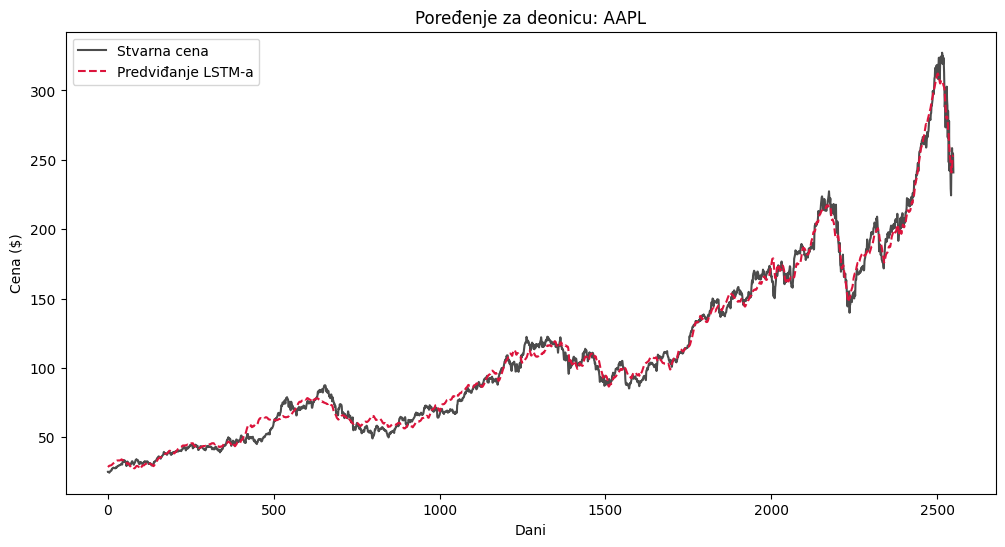

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prebacivanje modela u eval mod i predviđanje
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_tensor).cpu().numpy()

# 2. Vraćanje podataka iz skaliranog u originalni oblik
y_true = scaler.inverse_transform(y_tensor.cpu().numpy())
y_pred = scaler.inverse_transform(predictions_scaled)

# 3. Računanje ukupnih metrika za sve deonice
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"=== Evaluacija Modela ===")
print(f"MAE (Prosečna apsolutna greška): {mae:.2f} $")
print(f"RMSE (Koren srednje kvadratne greške): {rmse:.2f} $")

# 4. Vizuelna provera: Iscrtavanje stvarne vs predviđene cene za prvu deonicu
plt.figure(figsize=(12, 6))
plt.plot(y_true[:, 0], label="Stvarna cena", color="black", alpha=0.7)
plt.plot(y_pred[:, 0], label="Predviđanje LSTM-a", color="crimson", linestyle="--")
plt.title(f"Poređenje za deonicu: {df_pivot.columns[0]}")
plt.xlabel("Dani")
plt.ylabel("Cena ($)")
plt.legend()
plt.show()